In [1]:
print("Hello, I am ready!")

Hello, I am ready!


In [2]:
import pandas as pd

df = pd.read_csv("incident_event_log.csv")
print("Data loaded successfully!")
print("Shape:", df.shape)

Data loaded successfully!
Shape: (141712, 36)


In [3]:
df.head( )

,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,...,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at
0,INC0000045,New,True,0,0,0,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
1,INC0000045,Resolved,True,0,0,2,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
2,INC0000045,Resolved,True,0,0,3,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
3,INC0000045,Closed,False,0,0,4,True,Caller 2403,Opened by 8,29/2/2016 01:16,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
4,INC0000047,New,True,0,0,0,True,Caller 2403,Opened by 397,29/2/2016 04:40,...,False,Do Not Notify,?,?,?,?,code 5,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00


In [4]:
df.columns.tolist()

['number',
 'incident_state',
 'active',
 'reassignment_count',
 'reopen_count',
 'sys_mod_count',
 'made_sla',
 'caller_id',
 'opened_by',
 'opened_at',
 'sys_created_by',
 'sys_created_at',
 'sys_updated_by',
 'sys_updated_at',
 'contact_type',
 'location',
 'category',
 'subcategory',
 'u_symptom',
 'cmdb_ci',
 'impact',
 'urgency',
 'priority',
 'assignment_group',
 'assigned_to',
 'knowledge',
 'u_priority_confirmation',
 'notify',
 'problem_id',
 'rfc',
 'vendor',
 'caused_by',
 'closed_code',
 'resolved_by',
 'resolved_at',
 'closed_at']

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141712 entries, 0 to 141711
Data columns (total 36 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   number                   141712 non-null  object
 1   incident_state           141712 non-null  object
 2   active                   141712 non-null  bool  
 3   reassignment_count       141712 non-null  int64 
 4   reopen_count             141712 non-null  int64 
 5   sys_mod_count            141712 non-null  int64 
 6   made_sla                 141712 non-null  bool  
 7   caller_id                141712 non-null  object
 8   opened_by                141712 non-null  object
 9   opened_at                141712 non-null  object
 10  sys_created_by           141712 non-null  object
 11  sys_created_at           141712 non-null  object
 12  sys_updated_by           141712 non-null  object
 13  sys_updated_at           141712 non-null  object
 14  contact_type        

In [6]:
# Check what unique states exist
print(df['incident_state'].unique())

['New' 'Resolved' 'Closed' 'Active' 'Awaiting User Info'
 'Awaiting Problem' 'Awaiting Vendor' 'Awaiting Evidence' '-100']


In [7]:
print(df['incident_state'].value_counts())

incident_state
Active                38716
New                   36407
Resolved              25751
Closed                24985
Awaiting User Info    14642
Awaiting Vendor         707
Awaiting Problem        461
Awaiting Evidence        38
-100                      5
Name: count, dtype: int64


In [8]:
df_resolved = df[df['incident_state'].isin(['Resolved', 'Closed'])]
print("Filtered shape:", df_resolved.shape)

Filtered shape: (50736, 36)


In [9]:
df_resolved = df_resolved.copy()
df_resolved['opened_at'] = pd.to_datetime(df_resolved['opened_at'], dayfirst=True, errors='coerce')
df_resolved['resolved_at'] = pd.to_datetime(df_resolved['resolved_at'], dayfirst=True, errors='coerce')
df_resolved['closed_at'] = pd.to_datetime(df_resolved['closed_at'], dayfirst=True, errors='coerce')

print("Date columns converted!")
print("Missing resolved_at values:", df_resolved['resolved_at'].isna().sum())

Date columns converted!
Missing resolved_at values: 3119


In [10]:
df_resolved['resolution_time_hrs'] = (
    df_resolved['resolved_at'] - df_resolved['opened_at']
).dt.total_seconds() / 3600

# Drop rows where resolution time couldn't be calculated
df_time = df_resolved.dropna(subset=['resolution_time_hrs'])
df_time = df_time[df_time['resolution_time_hrs'] > 0]

print("Records with valid resolution time:", len(df_time))
print(df_time['resolution_time_hrs'].describe())

Records with valid resolution time: 47539
count    47539.000000
mean       182.137350
std        536.366536
min          0.016667
25%          0.433333
50%         22.966667
75%        156.683333
max       8070.166667
Name: resolution_time_hrs, dtype: float64


In [12]:
df.describe(include='object')

,number,incident_state,caller_id,opened_by,opened_at,sys_created_by,sys_created_at,sys_updated_by,sys_updated_at,contact_type,...,assigned_to,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at
count,141712,141712,141712,141712,141712,141712,141712,141712,141712,141712,...,141712,141712,141712,141712,141712,141712,141712,141712,141712,141712
unique,24918,9,5245,208,19849,186,11553,846,50664,5,...,235,2,253,182,5,4,18,217,18506,2707
top,INC0019396,Active,Caller 1904,Opened by 17,14/4/2016 20:42,?,?,Updated by 908,24/3/2016 18:40,Phone,...,?,Do Not Notify,?,?,?,?,code 6,Resolved by 15,?,24/3/2016 18:59
freq,58,38716,1425,41466,58,53076,53076,36162,420,140462,...,27496,141593,139417,140721,141468,141689,86583,15421,3141,3324


In [13]:
df.describe(include='all')

,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,...,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at
count,141712,141712,141712,141712.000000,141712.000000,141712.000000,141712,141712,141712,141712,...,141712,141712,141712,141712,141712,141712,141712,141712,141712,141712
unique,24918,9,2,NaN,NaN,NaN,2,5245,208,19849,...,2,2,253,182,5,4,18,217,18506,2707
top,INC0019396,Active,True,NaN,NaN,NaN,True,Caller 1904,Opened by 17,14/4/2016 20:42,...,False,Do Not Notify,?,?,?,?,code 6,Resolved by 15,?,24/3/2016 18:59
freq,58,38716,116726,NaN,NaN,NaN,132497,1425,41466,58,...,100740,141593,139417,140721,141468,141689,86583,15421,3141,3324
mean,NaN,NaN,NaN,1.104197,0.021918,5.080946,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,1.734673,0.207302,7.680652,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,0.000000,0.000000,1.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,1.000000,0.000000,3.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,1.000000,0.000000,6.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Makes charts look clean and professional
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize']=(12,5)

print("Libraries ready!")

Libraries ready!


In [16]:
# Count incidents per category
category_counts=df_resolved['category'].value_counts()
print(category_counts)

category
Category 42    7218
Category 26    6777
Category 53    5475
Category 46    4956
Category 32    3098
Category 9     2345
Category 37    2314
Category 23    2175
Category 20    2134
Category 57    2005
Category 61    1689
Category 24    1294
Category 45    1226
Category 28    1112
Category 51    1103
Category 35    1037
Category 34    1014
Category 40     888
Category 44     612
Category 19     513
Category 43     310
Category 13     255
Category 55     215
Category 17     164
Category 8      112
Category 22     107
Category 38      87
Category 56      81
Category 7       65
Category 54      60
Category 50      42
Category 33      34
Category 31      32
Category 63      22
Category 5       20
Category 2       18
?                17
Category 21      16
Category 59      14
Category 47      12
Category 52      10
Category 4       10
Category 62       8
Category 25       8
Category 29       7
Category 10       6
Category 16       4
Category 6        4
Category 58       2
Category 12

C:\Users\Sanket\AppData\Local\Temp\ipykernel_20068\2839563295.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.values, y=category_counts.index, palette='Blues_r')


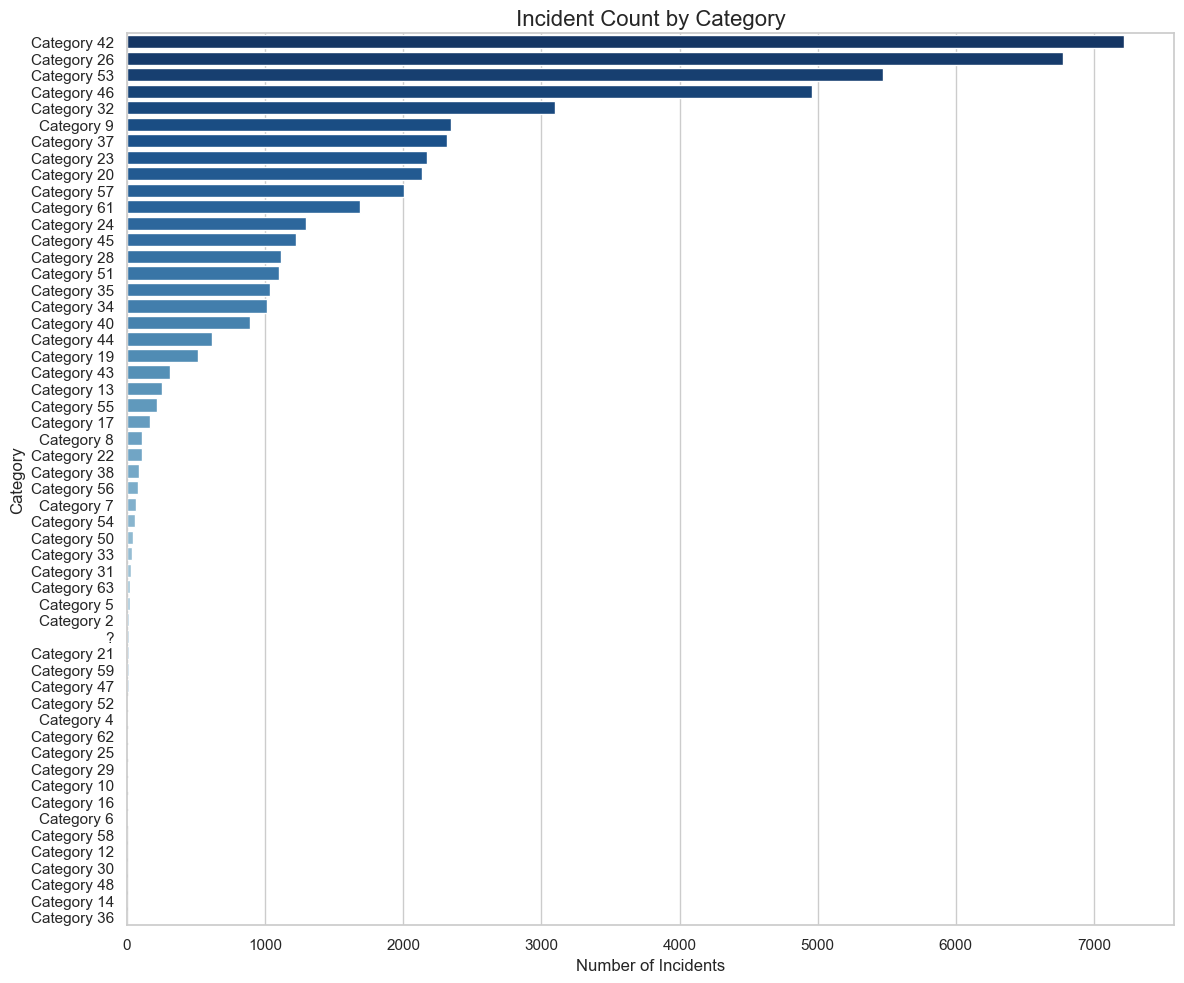

In [17]:
#Plot
plt.figure(figsize=(12,10))
sns.barplot(x=category_counts.values, y=category_counts.index, palette='Blues_r')

plt.title('Incident Count by Category', fontsize=16)
plt.xlabel('Number of Incidents')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

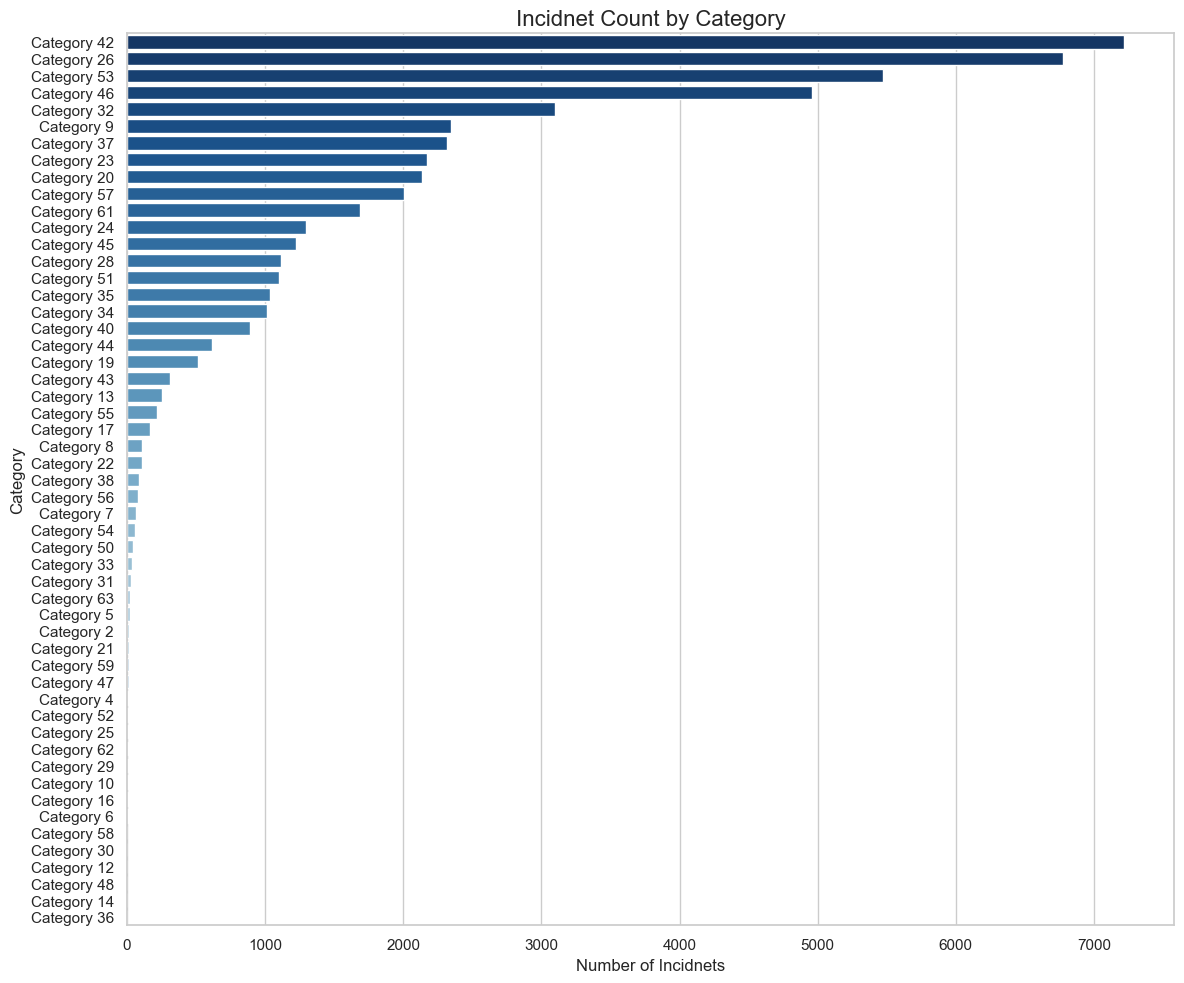

In [18]:
# Filter out unknown categories
df_resolved_clean=df_resolved[df_resolved['category']!='?']

category_counts=df_resolved_clean['category'].value_counts().reset_index()
category_counts.columns = ['category','count']

plt.figure(figsize=(12,10))
sns.barplot(data=category_counts, x='count', y='category', hue='category', 
palette='Blues_r', legend=False)

plt.title('Incidnet Count by Category', fontsize=16)
plt.xlabel('Number of Incidnets')
plt.ylabel('Category')
plt.tight_layout()
plt.show()


In [19]:
# Count incidents per priority
priority_counts = df_resolved['priority'].value_counts().reset_index()
priority_counts.columns = ['priority', 'count']

print(priority_counts)

       priority  count
0  3 - Moderate  47670
1       4 - Low   1547
2      2 - High    832
3  1 - Critical    687


In [20]:
print(priority_counts['priority'])

0    3 - Moderate
1         4 - Low
2        2 - High
3    1 - Critical
Name: priority, dtype: object


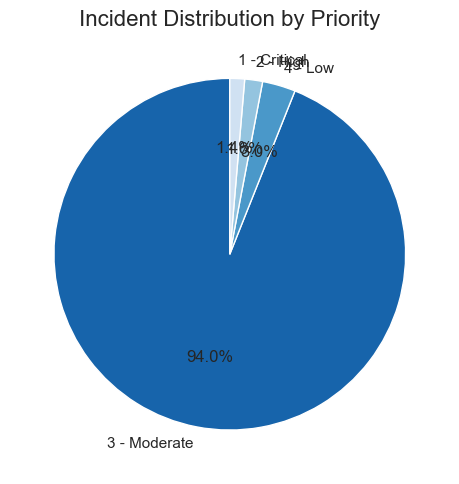

In [21]:
# Plot
plt.figure(figsize=(5, 5))
plt.pie(priority_counts['count'], 
        labels=priority_counts['priority'],
        autopct='%1.1f%%',
        colors=sns.color_palette('Blues_r', len(priority_counts)),
        startangle=90)

plt.title('Incident Distribution by Priority', fontsize=16)
plt.tight_layout()
plt.show()

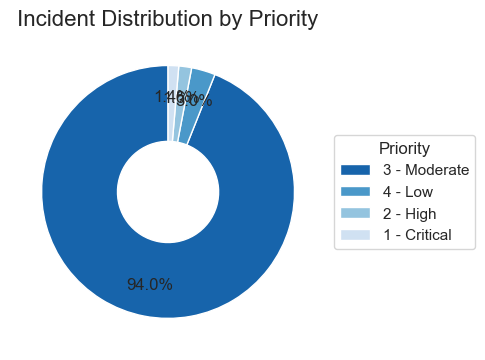

In [22]:
plt.figure(figsize=(5, 5))
wedges, texts, autotexts = plt.pie(
    priority_counts['count'],
    labels=None,
    autopct='%1.1f%%',
    colors=sns.color_palette('Blues_r', len(priority_counts)),
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.6)
)

plt.legend(wedges, priority_counts['priority'],
          title="Priority",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))

plt.title('Incident Distribution by Priority', fontsize=16)
plt.tight_layout()
plt.show()

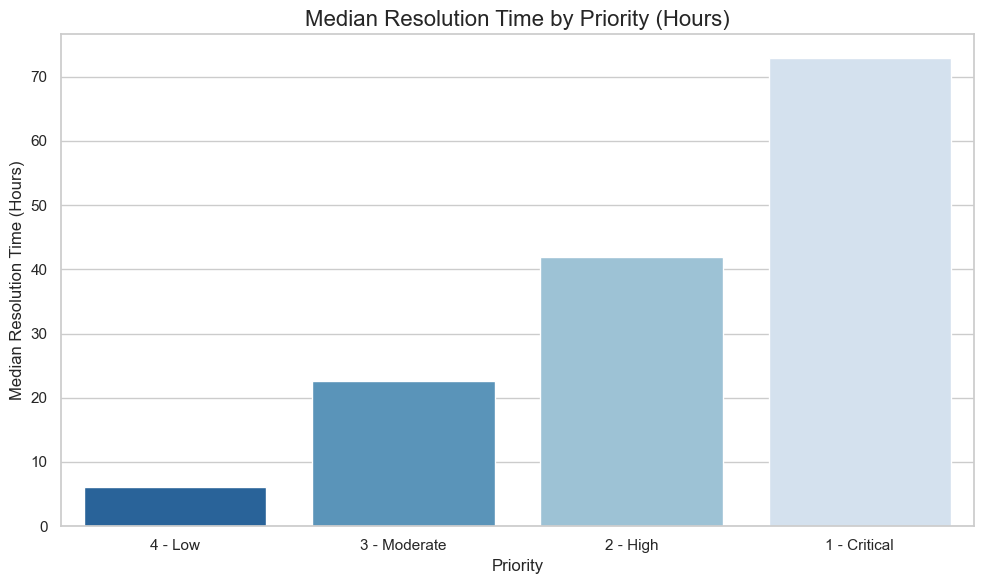

In [23]:
# Calculate average resolution time per priority
priority_resolution = df_time.groupby('priority')['resolution_time_hrs'].median().reset_index()
priority_resolution.columns = ['priority', 'median_resolution_hrs']
priority_resolution = priority_resolution.sort_values('median_resolution_hrs')

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=priority_resolution, x='priority', y='median_resolution_hrs',
            hue='priority', palette='Blues_r', legend=False)

plt.title('Median Resolution Time by Priority (Hours)', fontsize=16)
plt.xlabel('Priority')
plt.ylabel('Median Resolution Time (Hours)')

# Set y-axis ticks every 10 units
#plt.gca().yaxis.set_major_locator(ticker.MultipleLocator(5))

plt.tight_layout()
plt.show()

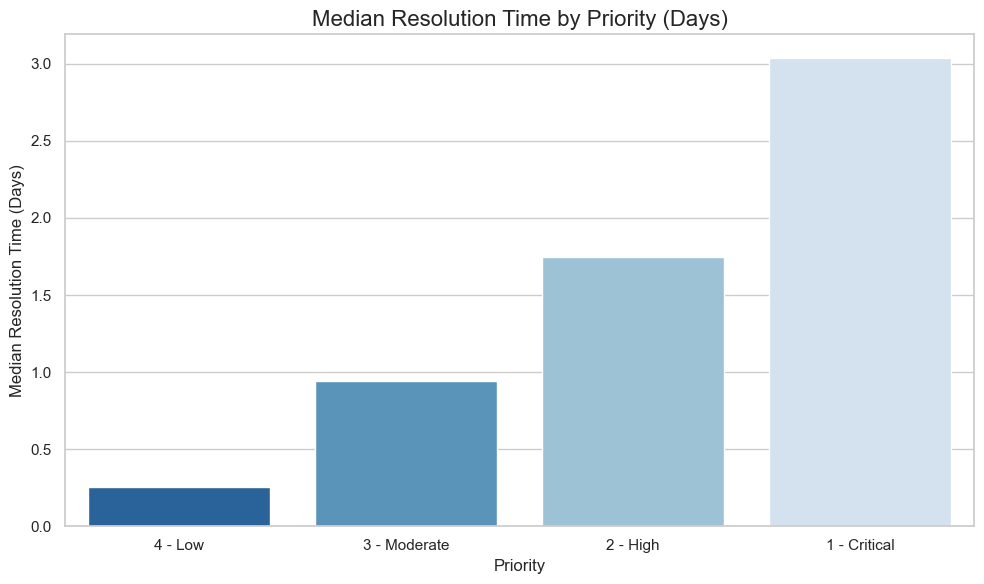

In [24]:
priority_resolution['median_resolution_days'] = priority_resolution['median_resolution_hrs'] / 24

plt.figure(figsize=(10, 6))
sns.barplot(data=priority_resolution, x='priority', y='median_resolution_days',
            hue='priority', palette='Blues_r', legend=False)

plt.title('Median Resolution Time by Priority (Days)', fontsize=16)
plt.xlabel('Priority')
plt.ylabel('Median Resolution Time (Days)')
plt.tight_layout()
plt.show()

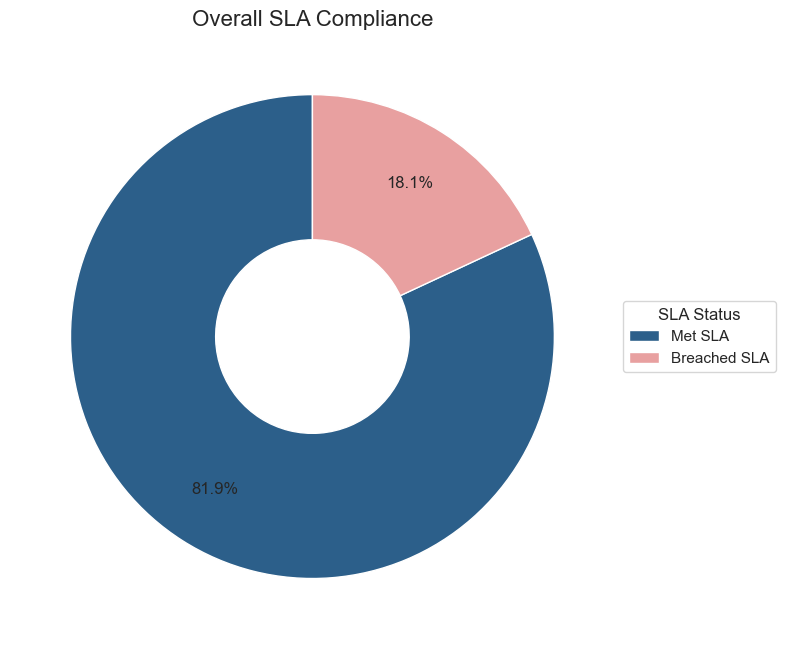

In [31]:
# Calculate overall SLA compliance
sla_counts = df_resolved['made_sla'].value_counts().reset_index()
sla_counts.columns = ['made_sla', 'count']
sla_counts['made_sla'] = sla_counts['made_sla'].map({True: 'Met SLA', False: 'Breached SLA'})

# Plot
plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(
    sla_counts['count'],
    labels=None,
    autopct='%1.1f%%',
    colors=['#2c5f8a', '#e8a0a0'],
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.6)
)

plt.legend(wedges, sla_counts['made_sla'],
          title="SLA Status",
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))

plt.title('Overall SLA Compliance', fontsize=16)
plt.tight_layout()
plt.show()

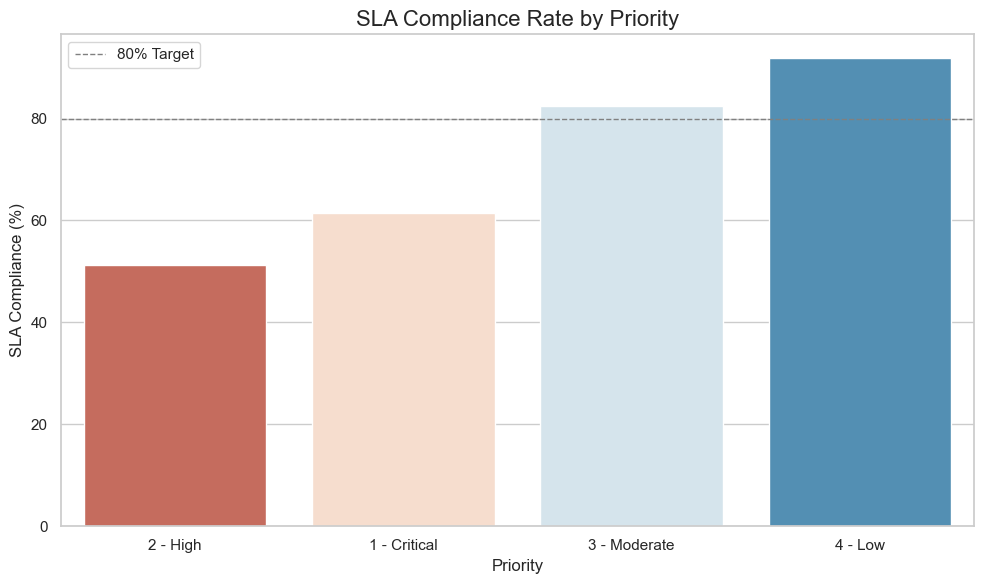

In [32]:
# SLA compliance by priority
sla_by_priority = df_resolved.groupby('priority')['made_sla'].mean().reset_index()
sla_by_priority.columns = ['priority', 'sla_compliance_rate']
sla_by_priority['sla_compliance_rate'] = sla_by_priority['sla_compliance_rate'] * 100
sla_by_priority = sla_by_priority.sort_values('sla_compliance_rate')

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=sla_by_priority, x='priority', y='sla_compliance_rate',
            hue='priority', palette='RdBu', legend=False)

plt.title('SLA Compliance Rate by Priority', fontsize=16)
plt.xlabel('Priority')
plt.ylabel('SLA Compliance (%)')
plt.axhline(y=80, color='gray', linestyle='--', linewidth=1, label='80% Target')
plt.legend()
plt.tight_layout()
plt.show()

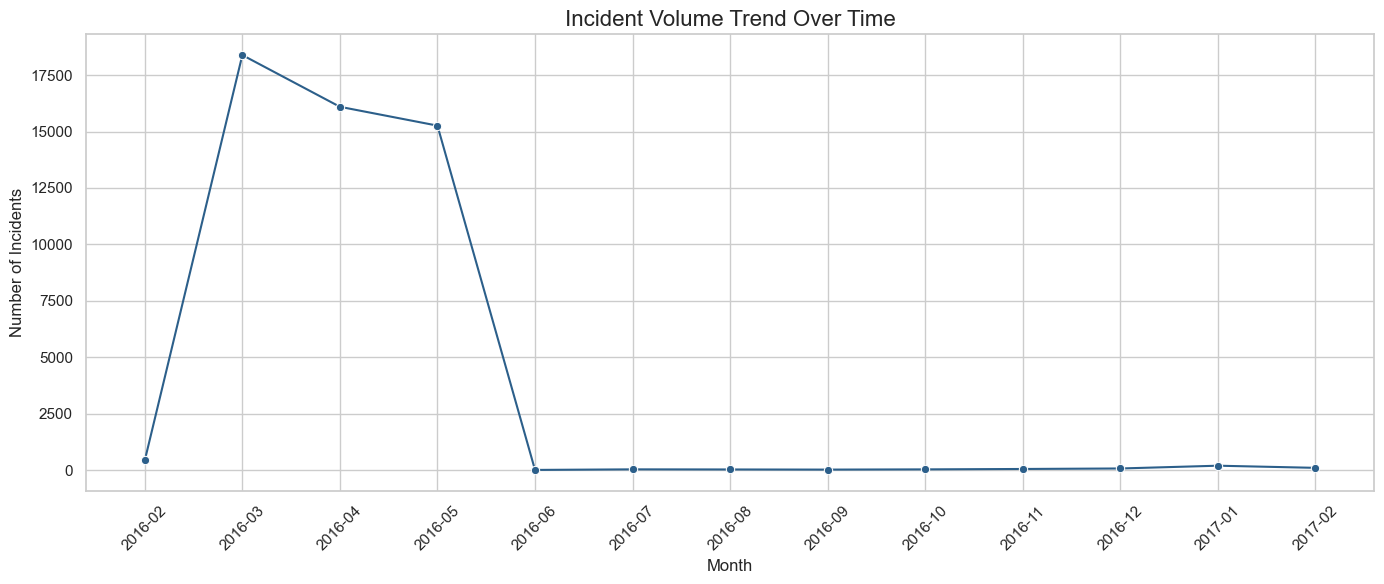

In [33]:
# Create a 'month' column from opened_at
df_resolved_clean = df_resolved.dropna(subset=['opened_at']).copy()
df_resolved_clean['month'] = df_resolved_clean['opened_at'].dt.to_period('M')

# Count incidents per month
monthly_trend = df_resolved_clean.groupby('month').size().reset_index()
monthly_trend.columns = ['month', 'incident_count']
monthly_trend['month'] = monthly_trend['month'].astype(str)

# Plot
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_trend, x='month', y='incident_count', marker='o', color='#2c5f8a')

plt.title('Incident Volume Trend Over Time', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:
print("Earliest incident opened:", df_resolved['opened_at'].min())
print("Latest incident opened:", df_resolved['opened_at'].max())
print("Total unique months:", df_resolved_clean['month'].nunique())

Earliest incident opened: 2016-02-29 01:16:00
Latest incident opened: 2017-02-16 14:17:00
Total unique months: 13


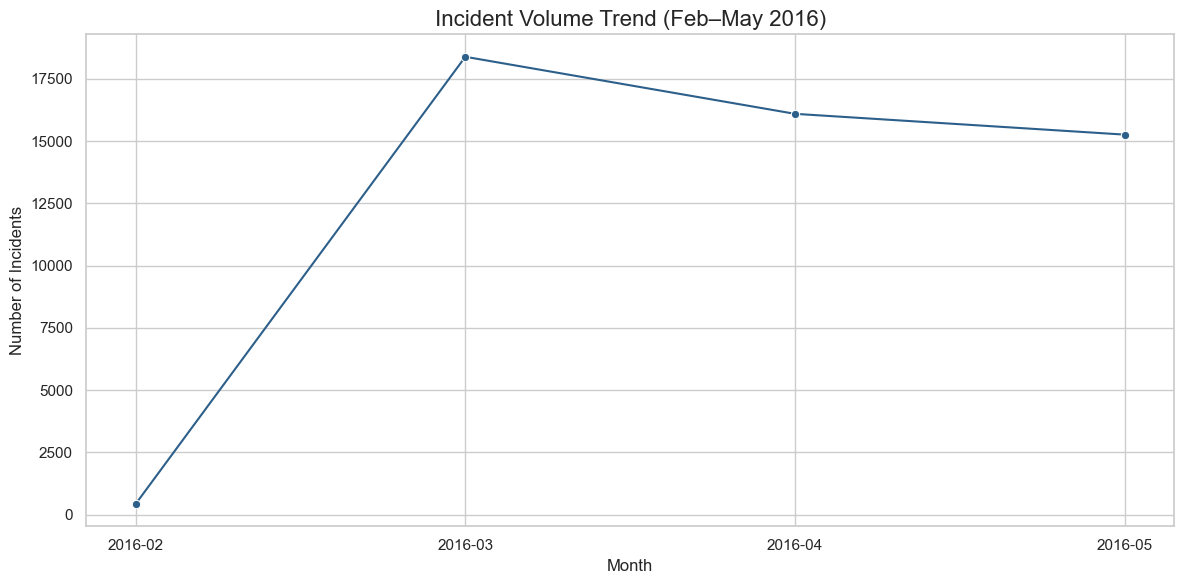

In [35]:
# Focus on the period with meaningful data
trend_focused = monthly_trend[monthly_trend['month'] <= '2016-05']

plt.figure(figsize=(12, 6))
sns.lineplot(data=trend_focused, x='month', y='incident_count', marker='o', color='#2c5f8a')

plt.title('Incident Volume Trend (Feb–May 2016)', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Number of Incidents')
plt.tight_layout()
plt.show()

In [40]:
# Export cleaned data for Power BI
df_resolved.to_csv("incidents_cleaned.csv", index=False)
print("File exported successfully!")

File exported successfully!


In [41]:
# Create a deduplicated version - keep only the LAST row per incident number
df_dedup = df_resolved.sort_values('sys_mod_count').drop_duplicates(subset='number', keep='last')

print("Original df_resolved shape:", df_resolved.shape)
print("Deduplicated df_dedup shape:", df_dedup.shape)

# Quick check - confirm INC0000045 now appears only once
print(df_dedup[df_dedup['number'] == 'INC0000045'])

Original df_resolved shape: (50736, 37)
Deduplicated df_dedup shape: (24918, 37)
       number incident_state  active  reassignment_count  reopen_count  \
3  INC0000045         Closed   False                   0             0   

   sys_mod_count  made_sla    caller_id     opened_by           opened_at  \
3              4      True  Caller 2403  Opened by  8 2016-02-29 01:16:00   

   ...         notify problem_id rfc vendor caused_by closed_code  \
3  ...  Do Not Notify          ?   ?      ?         ?      code 5   

       resolved_by         resolved_at           closed_at resolution_time_hrs  
3  Resolved by 149 2016-02-29 11:29:00 2016-03-05 12:00:00           10.216667  

[1 rows x 37 columns]


In [42]:
df_dedup.to_csv("incidents_cleaned_v2.csv", index=False)
print("File exported successfully!")

File exported successfully!


In [43]:
df_time_v2 = df_dedup.dropna(subset=['resolution_time_hrs'])
df_time_v2 = df_time_v2[df_time_v2['resolution_time_hrs'] > 0]

print("Records with valid resolution time:", len(df_time_v2))
print(df_time_v2['resolution_time_hrs'].describe())

Records with valid resolution time: 23323
count    23323.000000
mean       178.469515
std        533.183198
min          0.016667
25%          0.416667
50%         22.233333
75%        148.666667
max       8070.166667
Name: resolution_time_hrs, dtype: float64


In [44]:
priority_resolution_v2 = df_time_v2.groupby('priority')['resolution_time_hrs'].median().reset_index()
priority_resolution_v2.columns = ['priority', 'median_resolution_hrs']
priority_resolution_v2 = priority_resolution_v2.sort_values('median_resolution_hrs')
print(priority_resolution_v2)

       priority  median_resolution_hrs
3       4 - Low               6.033333
2  3 - Moderate              21.716667
1      2 - High              38.233333
0  1 - Critical              80.241667


In [45]:
sla_by_priority_v2 = df_dedup.groupby('priority')['made_sla'].mean().reset_index()
sla_by_priority_v2.columns = ['priority', 'sla_compliance_rate']
sla_by_priority_v2['sla_compliance_rate'] = sla_by_priority_v2['sla_compliance_rate'] * 100
sla_by_priority_v2 = sla_by_priority_v2.sort_values('sla_compliance_rate')
print(sla_by_priority_v2)

       priority  sla_compliance_rate
1      2 - High             0.490196
0  1 - Critical             1.851852
2  3 - Moderate            64.540186
3       4 - Low            84.108527


In [46]:
# Check made_sla values across multiple states for a few sample incidents
sample_check = df_resolved[df_resolved['number'].isin(['INC0000062', 'INC0000063'])][['number', 'incident_state', 'made_sla', 'sys_mod_count']]
print(sample_check)

        number incident_state  made_sla  sys_mod_count
30  INC0000062       Resolved      True              6
31  INC0000062         Closed     False              7
38  INC0000063       Resolved      True              6
39  INC0000063         Closed      True              7


In [47]:
# Check how many incidents have made_sla = True at Resolved but False at Closed (or vice versa)
sla_change_check = df_resolved.groupby('number')['made_sla'].nunique()
inconsistent_sla = sla_change_check[sla_change_check > 1]
print("Number of incidents where made_sla changed across states:", len(inconsistent_sla))
print("Out of total unique incidents:", df_resolved['number'].nunique())

Number of incidents where made_sla changed across states: 9114
Out of total unique incidents: 24918


In [48]:
# Sanity check: look at made_sla=False cases at Closed - are resolution times actually long?
closed_breach_check = df_dedup[(df_dedup['incident_state'] == 'Closed') & (df_dedup['made_sla'] == False)]['resolution_time_hrs'].describe()
print(closed_breach_check)

count    8930.000000
mean      438.311174
std       794.581689
min         0.000000
25%       113.079167
50%       201.400000
75%       395.050000
max      8070.166667
Name: resolution_time_hrs, dtype: float64


In [49]:
df_dedup.to_csv("incidents_cleaned_v2.csv", index=False)
print("File exported successfully!")

File exported successfully!
